In [21]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.common.qc import run_session_synapse_qc
from vip_slap2_analysis.behavior.preprocess import process_behavior_session
from vip_slap2_analysis.glutamate.extraction import process_glutamate_extraction
from vip_slap2_analysis.calcium.qc import run_calcium_qc
from vip_slap2_analysis.calcium.extraction import process_calcium_extraction

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
target_mice = [
#     803496,
    804730,804733,810196,
    809047,803121,
    826033,838410,834788
]

In [4]:
registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check","volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

In [68]:
datapath = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-21_09-23-34\analysis\derived\calcium\calcium_sequence_dff.npz"

In [69]:
data = np.load(datapath,allow_pickle=True)['data'][0]

In [70]:
dmd = 2
im_names = list(data[f'DMD{dmd}']['image_identity'].keys())

In [77]:
roi = 2

soma_data =[data[f'DMD{dmd}']['image_identity'][im]['repeated']['mean'][:,roi,:] for im in im_names]

In [78]:
im_colors = [
    '#c5cae9', '#ffcdd2', '#c8e6c9', '#ffe0b2',
    '#e1bee7', '#d7ccc8',
    '#9fd3f2']

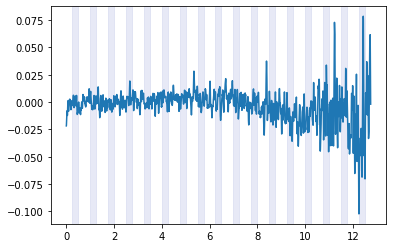

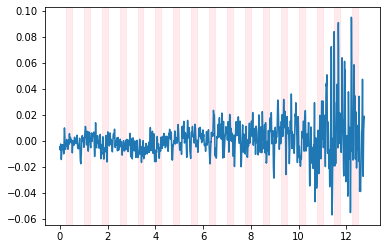

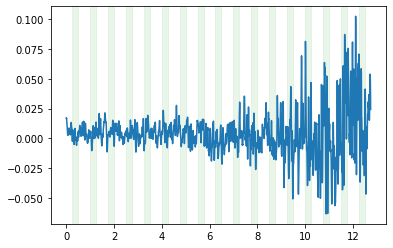

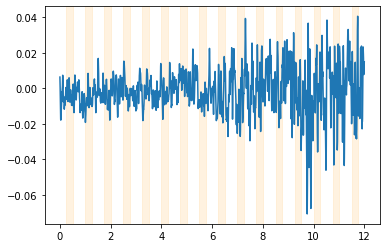

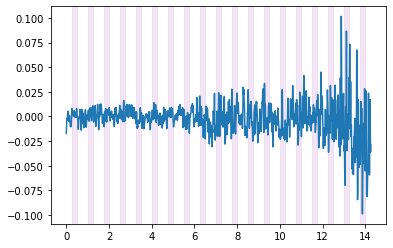

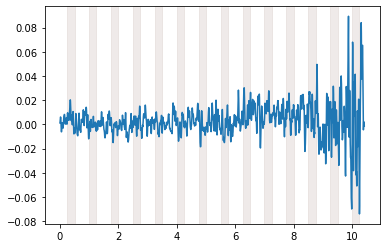

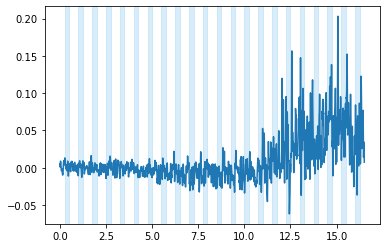

In [79]:
fs = 200
flash_start = 50 / fs      # 0.25 s
flash_dur = 50 / fs        # 0.25 s
gray_dur = 100 / fs        # 0.5 s
cycle_dur = flash_dur + gray_dur

for i,resp in enumerate(soma_data):
    shape = resp.shape
    
    n_flashes = shape[0]
    
    concat_traces = resp.reshape(shape[0] * shape[1])
    
    time  = np.linspace(0,len(concat_traces)/fs,len(concat_traces))
    
    fig,ax=plt.subplots()
    rolling = pd.DataFrame(concat_traces).rolling(5,min_periods=1).mean()
    ax.plot(time,rolling)
    
    for ii in range(n_flashes):
        start = flash_start + ii * cycle_dur
        end = start + flash_dur
        ax.axvspan(start, end, alpha=0.4, color=im_colors[i])

In [31]:
data[f'DMD{dmd}']['image_identity']

{'stimuli\\images_B\\100075.tiff': {'prechange': {'mean': array([], shape=(2, 0, 150), dtype=float64),
   'std': array([], shape=(2, 0, 150), dtype=float64),
   'counts': array([0, 0]),
   'n_sequences': array(41),
   'positions': array([-2, -1])},
  'repeated': {'mean': array([], shape=(15, 0, 150), dtype=float64),
   'std': array([], shape=(15, 0, 150), dtype=float64),
   'counts': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
   'n_sequences': array(41),
   'sequence_lengths': array([ 9,  9,  6,  9, 11,  7,  8,  9,  6, 10,  9,  7, 10,  6, 12,  7,  8,
           6,  7,  9,  6,  6,  8,  8, 10,  6, 10,  6,  9,  7,  6,  6,  8,  6,
          10, 13, 15,  7,  7,  7,  7]),
   'positions': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])},
  'terminal': {'mean': array([], shape=(0, 150), dtype=float64),
   'std': array([], shape=(0, 150), dtype=float64),
   'n_events': array(41),
   'n_finite': array([], shape=(0, 150), dtype=int32),
   'n_sequences': array(41),
 

In [41]:
np.linspace(50,shape[0]*(50+150),shape[0])

array([  50.   ,  259.375,  468.75 ,  678.125,  887.5  , 1096.875,
       1306.25 , 1515.625, 1725.   , 1934.375, 2143.75 , 2353.125,
       2562.5  , 2771.875, 2981.25 , 3190.625, 3400.   ])